# RFSoC 4x2 send/receive pulse 


In [2]:
# Imports and RFSoC connection
from qick import *
from qick.averager_program import AveragerProgram
from qick import QickConfig
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Set this depending on where this notebook is running.
# True  = running from Windows/PC and connecting to the board over Pyro
# False = running directly on the RFSoC board/PYNQ Jupyter
USE_REMOTE = True

if USE_REMOTE:
    import Pyro4
    Pyro4.config.SERIALIZER = "pickle"
    Pyro4.config.PICKLE_PROTOCOL_VERSION = 4

    ns_host = "10.1.9.48"   # change if your board IP/name server changed
    ns_port = 8888
    proxy_name = "myqick"

    ns = Pyro4.locateNS(host=ns_host, port=ns_port)
    soc = Pyro4.Proxy(ns.lookup(proxy_name))
    soccfg = QickConfig(soc.get_cfg())
else:
    soc = QickSoc()
    soccfg = soc

print(soccfg)


QICK running on RFSoC4x2, software version 0.2.414

Firmware configuration (built Wed Sep  6 18:49:29 2023):

	Global clocks (MHz): tProc dispatcher timing 409.600, RF reference 491.520
	Groups of related clocks: [tProc clock, DAC tile 0], [DAC tile 2], [ADC tile 0]

	2 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9830.400 Msps, fabric=614.400 MHz
		envelope memory: 65536 complex samples (6.667 us)
		32-bit DDS, range=9830.400 MHz
		DAC tile 0, blk 0 is DAC_B
	1:	axis_signal_gen_v6 - fs=9830.400 Msps, fabric=614.400 MHz
		envelope memory: 65536 complex samples (6.667 us)
		32-bit DDS, range=9830.400 MHz
		DAC tile 2, blk 0 is DAC_A

	2 readout channels:
	0:	axis_readout_v2 - configured by PYNQ
		fs=4423.680 Msps, decimated=552.960 MHz, 32-bit DDS, range=4423.680 MHz
		axis_avg_buffer v1.0 (no edge counter, no weights)
		memory 16384 accumulated, 1024 decimated (1.852 us)
		triggered by output 7, pin 14, feedback to tProc input 0
		ADC tile 0, blk 0 is ADC_D
	1:	axis_readout_v

In [3]:
# RFSoC 4x2 channel selection
# From your earlier RFSoC 4x2 printout, gen_ch=1 looked like DAC_A and gen_ch=0 looked like DAC_B.
# RO_CH depends on which ADC you physically cable to.
GEN_CH = 0   # likely DAC_A
RO_CH = 0    # likely ADC_A / first readout channel


In [4]:
class LoopbackProgram(AveragerProgram):
    def initialize(self):
        cfg = self.cfg
        res_ch = cfg["res_ch"]

        # Declare DAC/generator channel.
        self.declare_gen(ch=res_ch, nqz=cfg.get("nqz", 1))

        # Declare ADC/readout channel(s).
        for ch in cfg["ro_chs"]:
            self.declare_readout(
                ch=ch,
                length=cfg["readout_length"],
                freq=cfg["pulse_freq"],
                gen_ch=res_ch
            )

        # Convert user units to QICK register units.
        freq = self.freq2reg(cfg["pulse_freq"], gen_ch=res_ch, ro_ch=cfg["ro_chs"][0])
        phase = self.deg2reg(cfg["res_phase"], gen_ch=res_ch)
        gain = cfg["pulse_gain"]

        self.default_pulse_registers(ch=res_ch, freq=freq, phase=phase, gain=gain)

        style = cfg["pulse_style"]

        if style in ["flat_top", "arb"]:
            sigma = cfg["sigma"]
            self.add_gauss(ch=res_ch, name="measure", sigma=sigma, length=sigma*5)

        if style == "const":
            self.set_pulse_registers(ch=res_ch, style=style, length=cfg["length"])
        elif style == "flat_top":
            self.set_pulse_registers(ch=res_ch, style=style, waveform="measure", length=cfg["length"])
        elif style == "arb":
            self.set_pulse_registers(ch=res_ch, style=style, waveform="measure")
        else:
            raise ValueError(f"Unknown pulse_style: {style}")

        # Give the tProcessor time to configure before timed instructions.
        self.synci(200)

    def body(self):
        # measure() triggers ADC readout and fires the DAC pulse.
        self.measure(
            pulse_ch=self.cfg["res_ch"],
            adcs=self.ro_chs,
            pins=[0],
            adc_trig_offset=self.cfg["adc_trig_offset"],
            wait=True,
            syncdelay=self.us2cycles(self.cfg["relax_delay"])
        )


In [5]:
# Simple clean pulse test.
# Use this before trying waveform data from .npy files.
config = {
    "res_ch": GEN_CH,
    "ro_chs": [RO_CH],
    "nqz": 1,

    "reps": 1,
    "soft_avgs": 100,
    "relax_delay": 1.0,   # microseconds

    "res_phase": 0,       # degrees
    "pulse_style": "const",
    "length": 200,        # pulse length in generator clock ticks; longer makes it easier to catch
    "readout_length": 1000,

    "pulse_gain": 10000,  # start lower if connected to sensitive equipment
    "pulse_freq": 100,    # MHz
    "adc_trig_offset": 100,
}

prog = LoopbackProgram(soccfg, config)
iq_list = prog.acquire_decimated(soc, progress=True)


  0%|          | 0/100 [00:00<?, ?it/s]

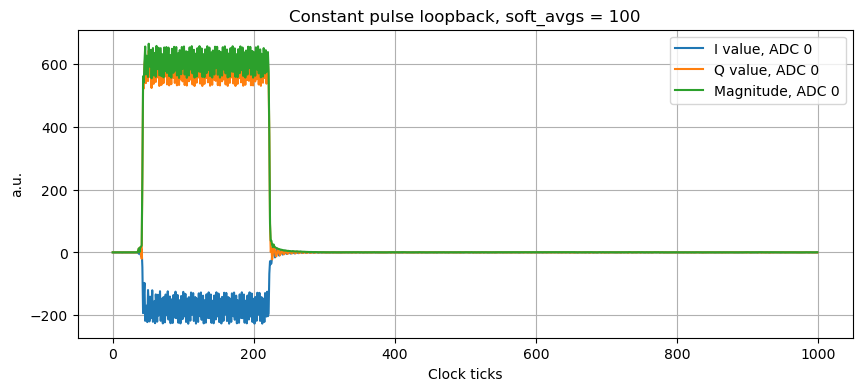

In [6]:
# Plot received ADC data.
plt.figure(figsize=(10, 4))
for ii, iq in enumerate(iq_list):
    I = iq[0]
    Q = iq[1]
    mag = np.abs(I + 1j*Q)

    plt.plot(I, label=f"I value, ADC {config['ro_chs'][ii]}")
    plt.plot(Q, label=f"Q value, ADC {config['ro_chs'][ii]}")
    plt.plot(mag, label=f"Magnitude, ADC {config['ro_chs'][ii]}")

plt.ylabel("a.u.")
plt.xlabel("Clock ticks")
plt.title("Constant pulse loopback, soft_avgs = " + str(config["soft_avgs"]))
plt.legend()
plt.grid(True)
plt.show()


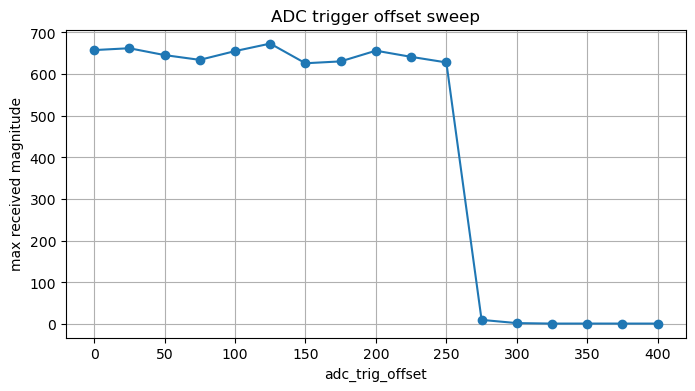

Best offset: 125


In [7]:
# Optional: sweep adc_trig_offset to find where the pulse lands in the ADC window.
offsets = list(range(0, 401, 25))
peak_mags = []

for offset in offsets:
    config["adc_trig_offset"] = offset
    prog = LoopbackProgram(soccfg, config)
    iq_list = prog.acquire_decimated(soc, progress=False)
    iq = iq_list[0]
    mag = np.abs(iq[0] + 1j*iq[1])
    peak_mags.append(np.max(mag))

plt.figure(figsize=(8, 4))
plt.plot(offsets, peak_mags, marker="o")
plt.xlabel("adc_trig_offset")
plt.ylabel("max received magnitude")
plt.title("ADC trigger offset sweep")
plt.grid(True)
plt.show()

# Put this back to the best-looking offset from the sweep.
best_offset = offsets[int(np.argmax(peak_mags))]
print("Best offset:", best_offset)
config["adc_trig_offset"] = best_offset


# Send an I/Q waveform


In [8]:
# Load interleaved I/Q waveform data from .npy
# Change this path to your X_train/X_test waveform file, not the y_train/y_test label file.
base = Path('.')

data = np.load(base /'X_2.npy', allow_pickle=False)
print("data shape:", data.shape)
print("data dtype:", data.dtype)


data shape: (500000, 1540)
data dtype: float64


In [9]:
# Pick one waveform and slice a window of I/Q pairs.
# For interleaved data, one complex sample uses two array entries: I then Q.
waveform_index = 0
start_pair = 0
num_iq_samples = 512   # keep this divisible by 16 when possible

start_location = 2 * start_pair
end_window = 2 * (start_pair + num_iq_samples)

wf = data[waveform_index, start_location:end_window]

print("wf length:", len(wf))
print("raw I first 10:", wf[0::2][:10])
print("raw Q first 10:", wf[1::2][:10])


wf length: 1024
raw I first 10: [380.2003068  375.72560124 371.29617176 366.9115603  362.57131342
 358.27498226 354.02212249 349.81229431 345.64506234 341.51999561]
raw Q first 10: [143.04866847 142.93491799 142.82272101 142.71205772 142.60290859
 142.49525429 142.38907576 142.28435414 142.18107083 142.07920744]


In [10]:
def interleaved_iq_to_qick(wf, scale=10000, make_mult=16):
    """
    Convert [I0, Q0, I1, Q1, ...] float/integer waveform data
    into QICK int16 idata/qdata arrays.
    """
    wf = np.asarray(wf, dtype=float)

    if len(wf) % 2 != 0:
        wf = wf[:-1]

    i_raw = wf[0::2]
    q_raw = wf[1::2]

    # Remove DC offset independently from I and Q.
    i_raw = i_raw - np.mean(i_raw)
    q_raw = q_raw - np.mean(q_raw)

    # Normalize both channels together so I/Q relative amplitude is preserved.
    max_abs = max(np.max(np.abs(i_raw)), np.max(np.abs(q_raw)))
    if max_abs == 0:
        raise ValueError("Waveform is all zeros, cannot scale.")

    i_norm = i_raw / max_abs
    q_norm = q_raw / max_abs

    i_data = np.round(scale * i_norm).astype(np.int16)
    q_data = np.round(scale * q_norm).astype(np.int16)

    # Make length divisible by generator samples-per-clock.
    n_trim = (len(i_data) // make_mult) * make_mult
    i_data = i_data[:n_trim]
    q_data = q_data[:n_trim]

    return i_data, q_data


i_data, q_data = interleaved_iq_to_qick(wf, scale=10000)

print("i_data shape/min/max:", i_data.shape, np.min(i_data), np.max(i_data))
print("q_data shape/min/max:", q_data.shape, np.min(q_data), np.max(q_data))
print("nonzero q_data count:", np.count_nonzero(q_data))


i_data shape/min/max: (512,) -2307 10000
q_data shape/min/max: (512,) -25 186
nonzero q_data count: 510


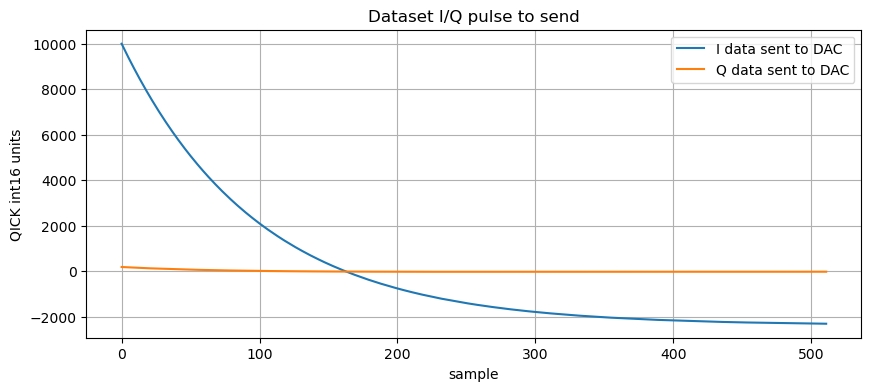

In [11]:
# Preview the exact I/Q arrays that will be uploaded to the RFSoC generator.
plt.figure(figsize=(10, 4))
plt.plot(i_data, label="I data sent to DAC")
plt.plot(q_data, label="Q data sent to DAC")
plt.legend()
plt.title("Dataset I/Q pulse to send")
plt.xlabel("sample")
plt.ylabel("QICK int16 units")
plt.grid(True)
plt.show()


In [12]:
class IQWaveformLoopbackProgram(AveragerProgram):
    def initialize(self):
        cfg = self.cfg
        res_ch = cfg["res_ch"]

        # Declare DAC/generator channel.
        self.declare_gen(ch=res_ch, nqz=cfg.get("nqz", 1))

        # Declare ADC/readout channel(s).
        for ch in cfg["ro_chs"]:
            self.declare_readout(
                ch=ch,
                length=cfg["readout_length"],
                freq=cfg["pulse_freq"],
                gen_ch=res_ch
            )

        # Upload arbitrary I/Q envelope waveform.
        if hasattr(self, "add_envelope"):
            self.add_envelope(
                ch=res_ch,
                name="dataset_waveform",
                idata=cfg["i_data"],
                qdata=cfg["q_data"]
            )
        else:
            self.add_pulse(
                ch=res_ch,
                name="dataset_waveform",
                idata=cfg["i_data"],
                qdata=cfg["q_data"]
            )

        freq = self.freq2reg(cfg["pulse_freq"], gen_ch=res_ch, ro_ch=cfg["ro_chs"][0])
        phase = self.deg2reg(cfg["res_phase"], gen_ch=res_ch)
        gain = cfg["pulse_gain"]

        self.set_pulse_registers(
            ch=res_ch,
            style="arb",
            freq=freq,
            phase=phase,
            gain=gain,
            waveform="dataset_waveform"
        )

        self.synci(200)

    def body(self):
        self.measure(
            pulse_ch=self.cfg["res_ch"],
            adcs=self.ro_chs,
            pins=[0],
            adc_trig_offset=self.cfg["adc_trig_offset"],
            wait=True,
            syncdelay=self.us2cycles(self.cfg["relax_delay"])
        )


In [13]:
# Send the dataset I/Q waveform and receive it back.
config_iq = {
    "res_ch": GEN_CH,
    "ro_chs": [RO_CH],
    "nqz": 1,

    "reps": 1,
    "soft_avgs": 100,
    "relax_delay": 1.0,

    "res_phase": 0,
    "pulse_gain": 10,     # start low; increase after confirming the pulse
    "pulse_freq": 100,      # MHz
    "readout_length": 1000,
    "adc_trig_offset": config.get("adc_trig_offset", 100),

    "i_data": i_data,
    "q_data": q_data,
}

prog = IQWaveformLoopbackProgram(soccfg, config_iq)
iq_list = prog.acquire_decimated(soc, progress=False)


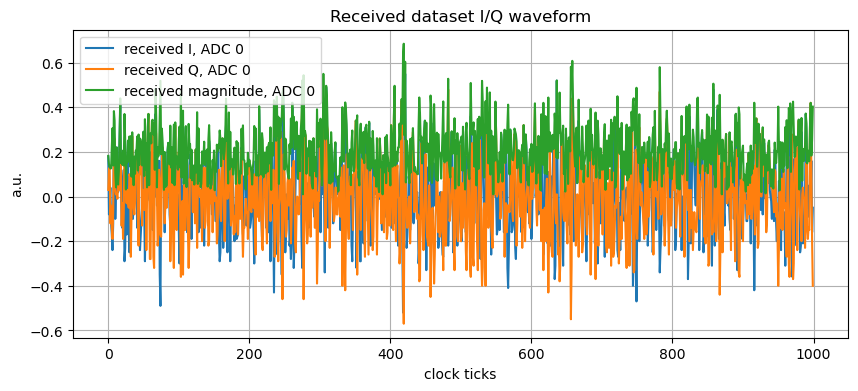

In [14]:
# Plot received waveform.
plt.figure(figsize=(10, 4))
for ii, iq in enumerate(iq_list):
    I = iq[0]
    Q = iq[1]
    mag = np.abs(I + 1j*Q)
    plt.plot(I, label=f"received I, ADC {config_iq['ro_chs'][ii]}")
    plt.plot(Q, label=f"received Q, ADC {config_iq['ro_chs'][ii]}")
    plt.plot(mag, label=f"received magnitude, ADC {config_iq['ro_chs'][ii]}")

plt.xlabel("clock ticks")
plt.ylabel("a.u.")
plt.title("Received dataset I/Q waveform")
plt.legend()
plt.grid(True)
plt.show()


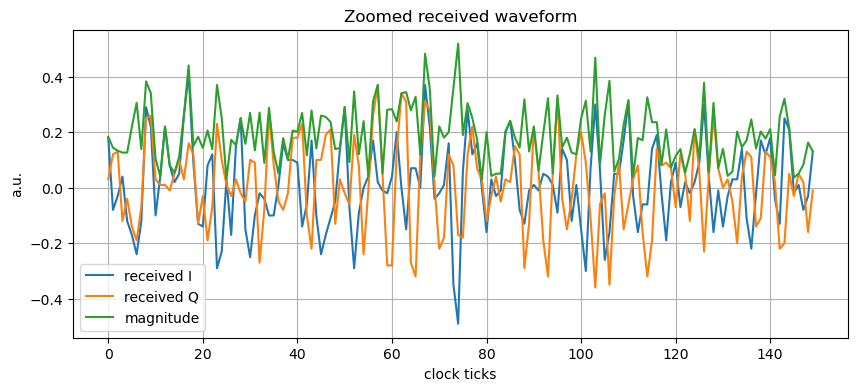

In [15]:
iq = iq_list[0]

I = iq[0]
Q = iq[1]
mag = np.abs(I + 1j*Q)

plt.figure(figsize=(10,4))
plt.plot(I[:150], label="received I")
plt.plot(Q[:150], label="received Q")
plt.plot(mag[:150], label="magnitude")
plt.legend()
plt.grid(True)
plt.title("Zoomed received waveform")
plt.xlabel("clock ticks")
plt.ylabel("a.u.")
plt.show()

In [16]:
iq = iq_list[0]

I = iq[0]
Q = iq[1]
mag = np.abs(I + 1j*Q)

signal_region = mag[:100]
noise_region = mag[200:]

print("max signal:", np.max(signal_region))
print("mean noise:", np.mean(noise_region))
print("std noise:", np.std(noise_region))
print("signal/noise ratio:", np.max(signal_region) / np.mean(noise_region))

max signal: 0.5186520991955976
mean noise: 0.21953059113157367
std noise: 0.11379342932446423
signal/noise ratio: 2.3625504606086913
